<a href="https://colab.research.google.com/github/sanghyeok03/Ai-Project/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
# 구글 콜랩에서 로컬 파일을 업로드

Saving creditcard.csv to creditcard.csv


In [ ]:
# pandas 라이브러리를 불러옵니다.
import pandas as pd
# 'creditcard.csv' 파일을 읽어 DataFrame으로 저장합니다.
df = pd.read_csv("creditcard.csv")
# 데이터프레임의 상위 5개 행을 출력합니다.
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# 타겟 컬럼 'Class'를 제외한 모든 컬럼을 X에 저장합니다.
X = df.drop("Class", axis=1)
# 타겟 컬럼 'Class'를 y에 저장합니다.
y = df["Class"]


In [ ]:
from sklearn.model_selection import train_test_split

# train_test_split 함수를 사용하여 데이터를 학습용과 테스트용으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("학습 데이터 수:", len(X_train)) # 학습 데이터 개수를 출력합니다.
print("테스트 데이터 수:", len(X_test)) # 테스트 데이터 개수를 출력합니다.


학습 데이터 수: 227845
테스트 데이터 수: 56962


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# RandomForestClassifier 모델을 생성합니다.
model = RandomForestClassifier(
    n_estimators=100,  # 트리 개수 100개로 설정
    class_weight='balanced', # 클래스 불균형 문제를 다루기 위한 가중치 설정
    random_state=42 # 결과 재현성을 위한 난수 시드 고정
)

model.fit(X_train, y_train) # 모델을 학습 데이터에 맞춰 학습시킵니다.


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test) # 테스트 데이터에 대해 예측을 수행합니다.

# 혼동 행렬을 출력합니다
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 분류 성능 보고서를 출력합니다.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[56863     1]
 [   24    74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.76      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



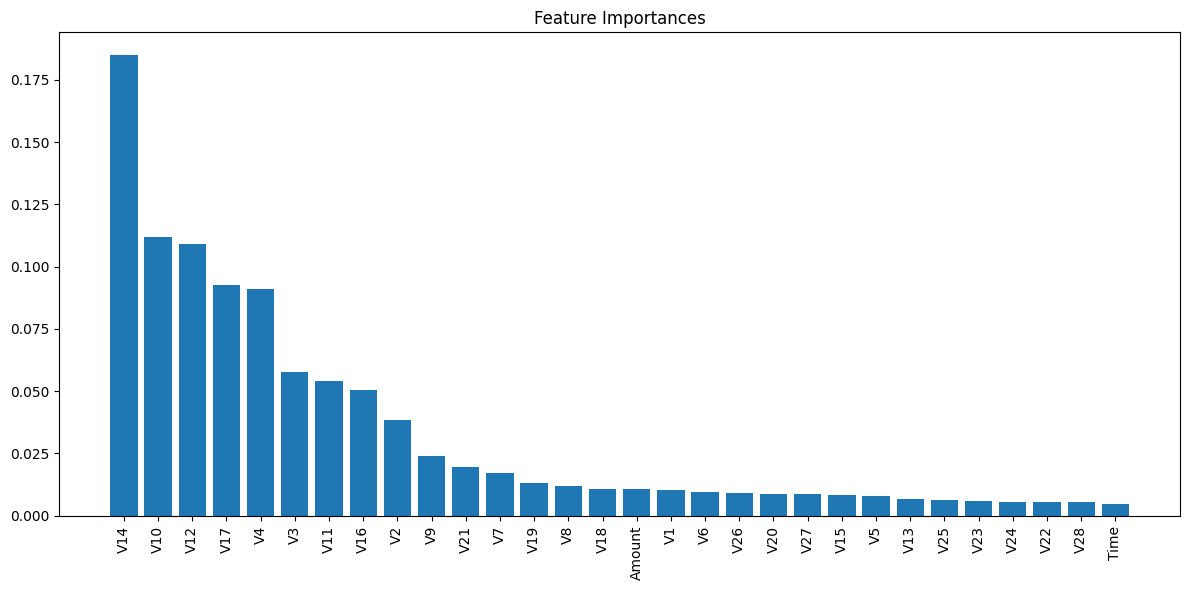

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_ # 모델에서 계산한 각 피처 중요도를 가져옵니다.
feature_names = X.columns # 피처 이름을 가져옵니다.
indices = importances.argsort()[::-1] # 중요도 내림차순 정렬을 위한 인덱스 배열을 만듭니다.

# 그래프로 피처 중요도를 시각화합니다.
plt.figure(figsize=(12,6)) # 그래프 크기 지정 (가로 12, 세로 6)
plt.title("Feature Importances") # 그래프 제목 설정
plt.bar(range(len(importances)), importances[indices]) # 중요도 순서대로 막대그래프 그리기
plt.xticks(range(len(importances)), feature_names[indices], rotation=90) # x축 눈금에 피처 이름 표시 및 90도 회전
plt.tight_layout() # 그래프 레이아웃 자동 조정 (글자가 겹치지 않도록)
plt.show() # 그래프 출력
